In [5]:
# Import important Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load Dataset
df = pd.read_csv('../dataset/Clean_Dataset.csv')
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [7]:
# Shape of Dataset
df.shape

(300153, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [9]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [30]:
df.isnull().sum()

airline             0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

In [12]:
# Remove unnecessary column
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [14]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(col)
    print(df[col].unique())
    print("-" * 70)

airline
['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
----------------------------------------------------------------------
flight
['SG-8709' 'SG-8157' 'I5-764' ... '6E-7127' '6E-7259' 'AI-433']
----------------------------------------------------------------------
source_city
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
----------------------------------------------------------------------
departure_time
['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
----------------------------------------------------------------------
stops
['zero' 'one' 'two_or_more']
----------------------------------------------------------------------
arrival_time
['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
----------------------------------------------------------------------
destination_city
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
----------------------------------------------------------------------

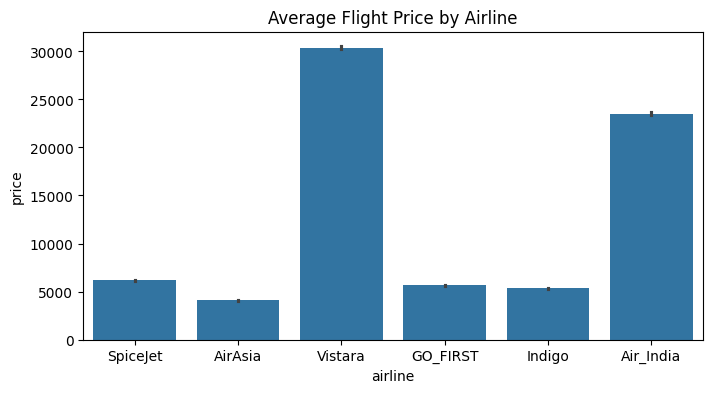

In [18]:
# Average flight price by airline
plt.figure(figsize=(8,4))

sns.barplot(x='airline', y='price',data=df)
plt.xticks(rotation=0)
plt.title("Average Flight Price by Airline")
plt.show()

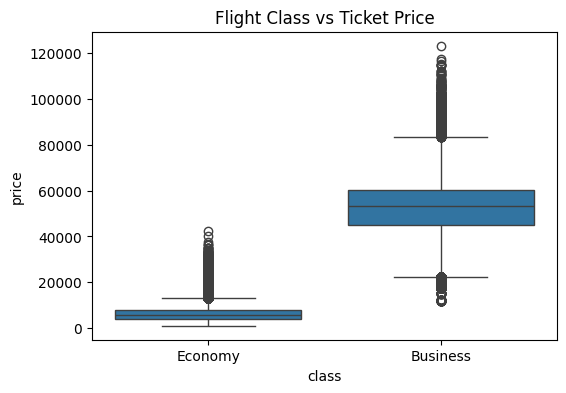

In [19]:
# Flight Class vs Price
plt.figure(figsize=(6,4))

sns.boxplot(x='class', y='price',data=df )
plt.title("Flight Class vs Ticket Price")
plt.show()

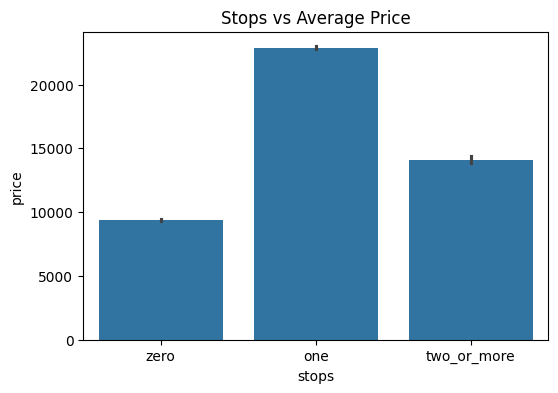

In [20]:
# Stops vs Price
plt.figure(figsize=(6,4))

sns.barplot(x='stops', y='price', data=df )
plt.title("Stops vs Average Price")
plt.show()

In [21]:
# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)
numeric_df.head()    

,duration,days_left,price
0,2.17,1,5953
1,2.33,1,5953
2,2.17,1,5956
3,2.25,1,5955
4,2.33,1,5955


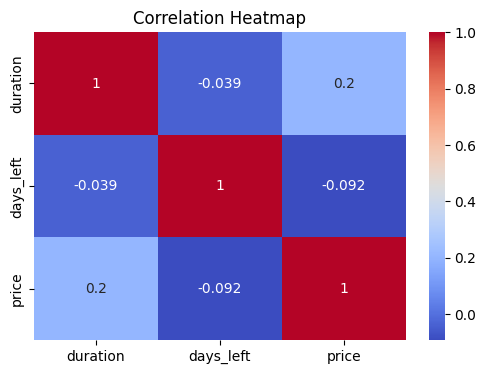

In [23]:
# Correlation Heatmap
plt.figure(figsize=(6,4))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [26]:
df.drop(columns=['flight'], inplace=True)

In [28]:
# Encode categorical columns

le = LabelEncoder()

categorical_cols = [
    'airline',
    'source_city',
    'departure_time',
    'stops',
    'arrival_time',
    'destination_city',
    'class'
]
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,2,2,2,5,5,1,2.17,1,5953
1,4,2,1,2,4,5,1,2.33,1,5953
2,0,2,1,2,1,5,1,2.17,1,5956
3,5,2,4,2,0,5,1,2.25,1,5955
4,5,2,4,2,4,5,1,2.33,1,5955


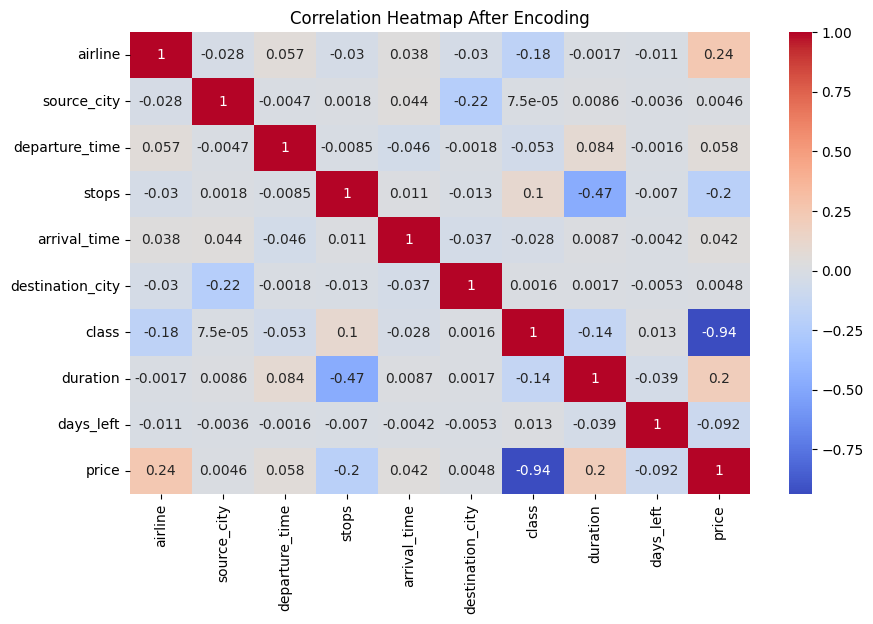

In [29]:
# Correlation Heatmap After Encoding

plt.figure(figsize=(10,6))

sns.heatmap( df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap After Encoding")

plt.show()

## Key Insights from Exploratory Data Analysis (EDA)
* The dataset contains more than 300,000 flight records, making it a large real-world regression dataset suitable for machine learning applications.
* No major missing values were found in the dataset, reducing the need for heavy data imputation or cleaning.
* Business class flights were significantly more expensive than economy class flights, indicating that ticket class is one of the strongest pricing       factors.
* Flight duration showed a positive relationship with ticket price, meaning longer flights generally tend to cost more.
* The number of stops also influenced pricing behavior, with ticket prices varying across non-stop, one-stop, and multi-stop flights.
* Correlation analysis revealed that features such as class, airline, duration, and stops had noticeable influence on flight pricing.
* Categorical columns were transformed into numerical form using Label Encoding to prepare the dataset for machine learning models.

### Model Building

In [31]:
# Features and Target
X = df.drop(columns=['price'])
y = df['price']

In [34]:
X

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,4,2,2,2,5,5,1,2.17,1
1,4,2,1,2,4,5,1,2.33,1
2,0,2,1,2,1,5,1,2.17,1
3,5,2,4,2,0,5,1,2.25,1
4,5,2,4,2,4,5,1,2.33,1
...,...,...,...,...,...,...,...,...,...
300148,5,1,4,0,2,3,0,10.08,49
300149,5,1,0,0,5,3,0,10.42,49
300150,5,1,1,0,5,3,0,13.83,49
300151,5,1,1,0,2,3,0,10.00,49


In [35]:
y

0          5953
1          5953
2          5956
3          5955
4          5955
          ...  
300148    69265
300149    77105
300150    79099
300151    81585
300152    81585
Name: price, Length: 300153, dtype: int64

In [36]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
# Linear Regression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [39]:
lr_pred = lr.predict(X_test)

In [40]:
# Decision Tree Regressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeRegressor(random_state=42)

In [41]:
dt_pred = dt.predict(X_test)

In [43]:
# Random Forest Regressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [44]:
rf_pred = rf.predict(X_test)

In [45]:
# Model Evaluation Function
def evaluate_model(y_test, predictions):

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    return mae, rmse, r2

In [47]:
# Evaluate Linear Regression
lr_mae, lr_rmse, lr_r2 = evaluate_model(y_test,lr_pred)
# Evaluate Decision Tree
dt_mae, dt_rmse, dt_r2 = evaluate_model(y_test,dt_pred)
# Evaluate Random Forest
rf_mae, rf_rmse, rf_r2 = evaluate_model(y_test,rf_pred)

In [48]:
# Model Comparison Table

results = pd.DataFrame({
         'Model': ['Linear Regression','Decision Tree','Random Forest'],
         'MAE': [lr_mae,dt_mae,rf_mae],
         'RMSE': [lr_rmse,dt_rmse,rf_rmse],
         'R2 Score': [lr_r2, dt_r2, rf_r2] 
         })
results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4624.994868,7014.309680,0.904554
1,Decision Tree,1171.294190,3540.007674,0.975689
2,Random Forest,1091.443544,2786.496710,0.984937


#### Since Random Forest has highest R2 score and relatively lower MAE and RMSE scores, hence Random Forest is the best model here..

In [50]:
# Custom Flight Input
custom_input = pd.DataFrame({'airline': [2],
                             'source_city': [5],
                             'departure_time': [1],
                             'stops': [0],
                             'arrival_time': [4],
                             'destination_city': [2],
                             'class': [1],
                             'duration': [2.17],
                             'days_left': [15]
                            })

In [51]:
# Predict Flight Price

predicted_price = rf.predict(custom_input)
print("Predicted Flight Price: ₹", round(predicted_price[0], 2))

Predicted Flight Price: ₹ 3722.47


In [52]:
# Save Model
import pickle
pickle.dump(rf,open('../models/flight_price_model.pkl', 'wb'))